In [91]:
import numpy as np
import sympy as sp
import scipy.linalg as la
import numpy.linalg as nla
import matplotlib.pyplot as plt
import PIL.Image as Image

# **Python Assignment 2**
Math 313 Section 008 - Spring 2026

---

# Matrix multiplications

Let $A$ and $B$ be two matrices with sizes $n \times m$ and $m \times l$ respectively, then we can define the matrix multiplication $AB$. By viewing $A$ and $B$ as linear transformations, their product $AB$ is the matrix representation of the composition:

$$T_A \circ T_B \colon \mathbb{R}^l \xrightarrow{T_B} \mathbb{R}^m \xrightarrow{T_A} \mathbb{R}^n$$

where $T_A$ and $T_B$ are linear transformations with standard matrices $A$ and $B$ respectively.

In particular, consider a square matrix $A$ with size $n \times n$, we can also define
$$ A^k = \underbrace{A \cdot A \cdots A}_{\text{$k$ times}}$$
which on the other hand, can be viewed as composing the linear transformation with $A$ as its standard matrix, $k$ times.

## Example 1

In this example, we will introduce a special and useful type of matrices, called **Toeplitz matrix**. Generally speaking, any matrix which has constant diagonals (all diagonals, not only the main diagonal) is called a Toeplitz matrix. For example,

$$\begin{bmatrix}
a & b & c & d \\
e & a & b & c \\
f & e & a & b \\
g & f & e & a
\end{bmatrix}$$

A Toeplitz matrix can be used as a blurring operator to blur a image. Mathematically, we can store a $16 \times 16$ image in a $16 \times 16$ matrix. Let $A$ be a $16 \times 16$ Toeplitz matrix, we consider this blurring process as a system of equations:
$$AX = B + \delta$$
where


*   $A$ is what we call a blurring operator, represented by a Toeplitz matrix;
*   $X$ is the input image (before blurring);
*   $B$ is the blurred image (after blurring);
*   $\delta$ is an additive Gaussian noise.



In [92]:
# generate a Toeplitz matrix
# the first argument indicates the first column
# the second argument indicates the first row (the first entry of the row is ignored)
A = la.toeplitz([1, 2, 3, 4], [1, 4, 5, 6])
display(sp.Matrix(A))
print('')

# lower triangular Toeplitz
B = la.toeplitz([1, 2, 3, 4], [0, 0, 0, 0])
display(sp.Matrix(B))
print('')

# upper triangular Toeplitz
C = la.toeplitz([1, 0, 0, 0], [1, 2, 3, 4])
display(sp.Matrix(C))
print('')

# symmetric (if only one argument is specified, the first row and the first column are the same)
D = la.toeplitz([1, 2, 3, 4])
display(sp.Matrix(D))
print('')

Matrix([
[1, 4, 5, 6],
[2, 1, 4, 5],
[3, 2, 1, 4],
[4, 3, 2, 1]])

Matrix([
[1, 0, 0, 0],
[2, 1, 0, 0],
[3, 2, 1, 0],
[4, 3, 2, 1]])

Matrix([
[1, 2, 3, 4],
[0, 1, 2, 3],
[0, 0, 1, 2],
[0, 0, 0, 1]])

Matrix([
[1, 2, 3, 4],
[2, 1, 2, 3],
[3, 2, 1, 2],
[4, 3, 2, 1]])

Let us first represent an image using a matrix $X$. Let $A$ and $B$ be two Toeplitz matrices. Then the left multiplication $AX$ gives a vertical blurring (column-wisely), while the right multiplication $XB$ produces a horizontal blurring (row-wisely).

In [93]:
! git clone https://github.com/zhengninghu/m313LinearAlgebra_Python.git

import os
image_file = os.path.join('m313LinearAlgebra_Python', 'Assignment_2', 'otter.jpg')

fatal: destination path 'm313LinearAlgebra_Python' already exists and is not an empty directory.


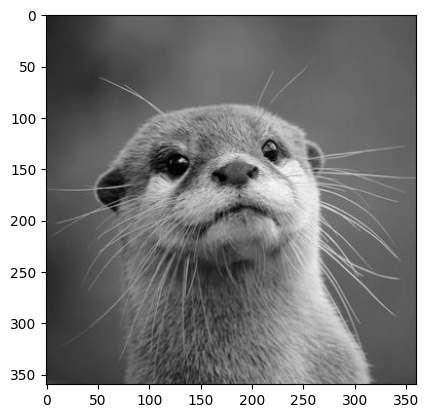

[[1.   0.   0.   ... 0.   0.   0.  ]
 [0.96 1.   0.   ... 0.   0.   0.  ]
 [0.92 0.96 1.   ... 0.   0.   0.  ]
 ...
 [0.   0.   0.   ... 1.   0.   0.  ]
 [0.   0.   0.   ... 0.96 1.   0.  ]
 [0.   0.   0.   ... 0.92 0.96 1.  ]]


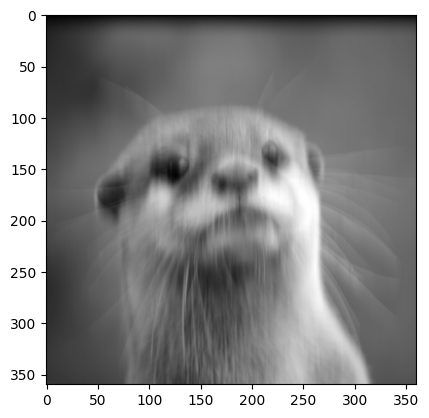

In [94]:
otter = Image.open(image_file).convert('L')
otter = np.array(otter)
plt.imshow(otter, cmap='gray')
plt.show()
# shape of the image
h, w = otter.shape

# generate a vertical blurring matrix
# a Toeplitz matrix where the values decrease from the main diagonal
row = np.zeros(h)
col = np.zeros(w)
step = 25
col[:step] = np.linspace(1, 0, step, endpoint=False)
row[0] = 1 # not necessary though
V = la.toeplitz(col, row)
print(V)
blurred_otter = V @ otter  # apply blurring
plt.imshow(blurred_otter, cmap='gray')
plt.show()

## Problem 1 -- Blurring images

Define another Toeplitz matrix $H$ representing the horizontal blurring. Do the followings:


*   Blur the image otter horizontally and show image after blurring, and
*   Do both vertical and horizontal blurring simultaneously, and show image.


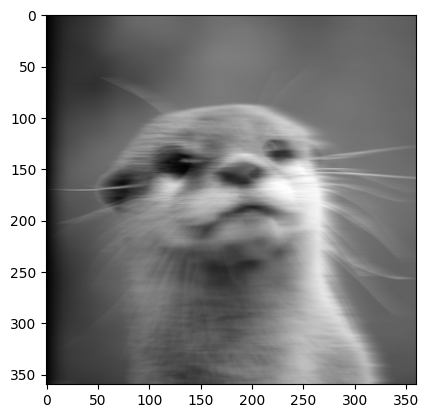

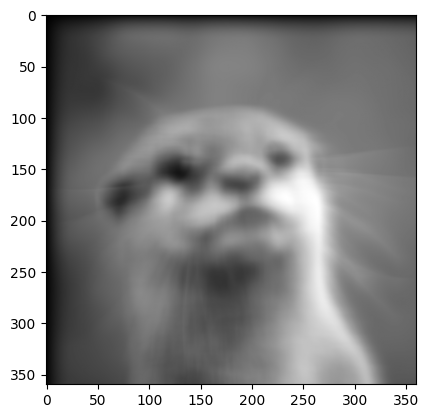

In [95]:
row = np.zeros(h)
col = np.zeros(w)
step = 25
row[:step] = np.linspace(1, 0, step, endpoint=False)
col[0] = 1

### Solution ###
# blur horizontally and show image
H = la.toeplitz(col, row)
blurred_otter = otter @ H # apply blurring
plt.imshow(blurred_otter, cmap='gray')
plt.show()

### Solution ###
#################################
### Solution ###
# blur vertically AND horizontally and show image
blurred_otter = V @ otter @ H  # apply blurring
plt.imshow(blurred_otter, cmap='gray')
plt.show()
### Solution ###

## Example 2

We start with a square matrix $A$ mentioned in class, and take powers $A^n$ for any positive integer $n$.

$$A = \begin{bmatrix}
0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
\end{bmatrix}$$

One can easily see how the diagonal $1$'s are shifted towards the upper right corner. And the power $A^n$ stabilizes to the zero matrix when the exponent $n$ is greater or equal to $10$.

In [96]:
# generate such matrix A
A1 = np.zeros((10, 10), dtype=int)
for i in range(1, 10):
  A1[i - 1, i] = 1
display(sp.Matrix(A1))
print('')

# A is actually of Toeplitz-type (see Example 1)
# so A can also be constructed in the following way
row = np.zeros(10, dtype=int)
row[1] = 1
col = np.zeros(10, dtype=int)
A2 = la.toeplitz(col, row)
display(sp.Matrix(A2))

Matrix([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

Matrix([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

In [97]:
# let us compute A^n
for n in range(1, 11):
    print(f'n = {n}')
    display(sp.Matrix(nla.matrix_power(A1, n)))

n = 1


Matrix([
[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

n = 2


Matrix([
[0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

n = 3


...

Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

n = 9


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

n = 10


Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

## Problem 2 -- Permutation matrices

An $n \times n$ permutation matrix is a square matrix obtained from the $n \times n$ identity matrix $I_n$ by a permutation of rows. Thus a permutation matrix is always row equivalent to the identity matrix (and hence invertible). In other words, every row and column of a permutation matrix contain exactly one nonzero entry which is $1$. For example, the following is a $4 \times 4$ permutation matrix:

$$P = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}$$

If we apply the permutation matrix by left multiplication to the vector $\textbf{v} = (1,2,3,4)$, this will tell you how a set of $4$ elements gets permuted by this permutation matrix $P$.

$$P\textbf{v} = \begin{bmatrix}
0 & 1 & 0 & 0 \\
0 & 0 & 0 & 1 \\
1 & 0 & 0 & 0 \\
0 & 0 & 1 & 0
\end{bmatrix}\begin{bmatrix}
1 \\ 2 \\ 3 \\ 4
\end{bmatrix} = \begin{bmatrix}
2 \\ 4 \\ 1 \\ 3
\end{bmatrix}$$

It means that row 1 is moved to row 3, row 3 is moved to row 4, row 4 is moved to row 2 and row 2 is moved to row 1.

In [98]:
# generate the permutation matrix P
I = np.eye(4, dtype=int)

# or permuting rows of I
P = I[[1, 3, 0, 2]]
# generate P by permuting columns of I
P1 = I[:, [2, 0, 3, 1]]

display(sp.Matrix(P))
print('')
display(sp.Matrix(P1))

Matrix([
[0, 1, 0, 0],
[0, 0, 0, 1],
[1, 0, 0, 0],
[0, 0, 1, 0]])

Matrix([
[0, 1, 0, 0],
[0, 0, 0, 1],
[1, 0, 0, 0],
[0, 0, 1, 0]])

For any $n \times n$ permutation marix $P$, there always exists a positive integer $k$ such that $P^k = I_n$. The **smallest** positive integer satisfying this property is called the *order* of $P$, and the order of $P$ is always less or equal to $e^{n/e}$.



### Problem 2 Part 1

Write a function that automatically determines the order of a given permutation matrix.

In [99]:
def orderPermutation(P):
    """Function to return the order of an input permutation matrix"""
    ### Solution ###
    n=1
    while (np.array(np.eye(len(P), dtype=int))!=np.array(sp.Matrix(nla.matrix_power(P, n)))).any():
      n+=1
    return n
    ### Solution ###

### Problem 2 Part 2

Start with the following $10 \times 10$ permutation matrix $Q$, use the function `orderPermutation` from above Part 1 to get the order of $Q$.

In [100]:
# generate a permutation matrix Q
I = np.eye(10, dtype=int)
Q = I[[9, 4, 5, 7, 6, 2, 0, 8, 3, 1]]

# what is the order of Q?
### Solution ###
print(orderPermutation(Q))

### Solution ###

30


# Elementary matrices and LU Decomposition

Elementary matrices are square matrices which are obtained by applying a single elementary row operation to the identity matrix. One advantage of introducing elementary matrices is that since every invertible $n \times n$ matrix $A$ has RREF the identity matrix $I_n$, i.e.,

$$E_k\cdots E_2E_1 A = I_n$$

the inverse matrix of $A$, denoted by $A^{-1}$ can be computed by applying to $I_n$ the same sequence of row operations which convert $A$ to $I_n$. Namely,

$$A^{-1} = E_k\cdots E_2E_1 I_n.$$

The process of Gaussian elimination gives rise to the LU Decomposition, which says that for any square matrix $A$ it can be written as

$$A = PLU$$

where $P$ is a permutation matrix (defined in Problem 2), $L$ is a lower triangular matrix, and $U$ is a upper triangular matrix. In particular, if the matrix $A$ can be row reduced to an echelon form by only applying **two** types of elementary row operations "rescaling a row" and "replace a row by the sum of itself and a multiple of another row", then $A$ can be decomposed as

$$A = LU$$

where again, $L$ is some lower triangular matrix and $U$ is a upper triangular matrix.

## Example 3

Let's consider a matrix

$$A = \begin{bmatrix}
1 & -2 & 1 \\
2 & 3 & 2 \\
1 & -2 & -4
\end{bmatrix}$$

and do LU decomposition to $A$.

In [101]:
A = np.array([[1, -2, 1], [2, 3, 2], [1, -2, -4]])
P, L, U = la.lu(A)
display(sp.Matrix(P))
display(sp.Matrix(L))
display(sp.Matrix(U))

Matrix([
[0.0, 1.0, 0.0],
[1.0, 0.0, 0.0],
[0.0, 0.0, 1.0]])

Matrix([
[1.0, 0.0, 0.0],
[0.5, 1.0, 0.0],
[0.5, 1.0, 1.0]])

Matrix([
[2.0,  3.0,  2.0],
[0.0, -3.5,  0.0],
[0.0,  0.0, -5.0]])

## Problem 3

Why LU Decomposition? One reason is that when considering a linear system $A\textbf{x} = \textbf{b}$, it is much easier to solve when $A$ is a triangular matrix. In this case, instead of using **nla.solve** we can use **la.solve_triangular** to speed up the computation.

Let us start with a Toeplitz matrix $A$ and a vector $\textbf{b}$. The goal is to solve $A\textbf{x} = \textbf{b}$ using LU Decomposition.


*   Decompose $A = PLU$;
*   Solve the linear systems $P\textbf{z} = \textbf{b}$ using `la.solve`, and solve $L\textbf{y} = \textbf{z}$ and $U\textbf{x} = \textbf{y}$ using `la.solve_triangular`.



In [102]:
# generate A and b
row = np.array([-4, 2, 0, 0, 0, 0, 0, 0, 0, -6])
A = la.toeplitz(row)
display(sp.Matrix(A))
print('')
b = np.ones(10)
# Do LU Decomposition of A
P, L, U = la.lu(A)

# solve Pz = b
z = la.solve(P, b)

### Solution ###
# solve Ly = z
y=la.solve(L, z)

# solve Ux = y
x=la.solve(U, y)

### Solution ###
display(sp.Matrix(x))

Matrix([
[-4,  2,  0,  0,  0,  0,  0,  0,  0, -6],
[ 2, -4,  2,  0,  0,  0,  0,  0,  0,  0],
[ 0,  2, -4,  2,  0,  0,  0,  0,  0,  0],
[ 0,  0,  2, -4,  2,  0,  0,  0,  0,  0],
[ 0,  0,  0,  2, -4,  2,  0,  0,  0,  0],
[ 0,  0,  0,  0,  2, -4,  2,  0,  0,  0],
[ 0,  0,  0,  0,  0,  2, -4,  2,  0,  0],
[ 0,  0,  0,  0,  0,  0,  2, -4,  2,  0],
[ 0,  0,  0,  0,  0,  0,  0,  2, -4,  2],
[-6,  0,  0,  0,  0,  0,  0,  0,  2, -4]])

Matrix([
[-0.625],
[-2.625],
[-4.125],
[-5.125],
[-5.625],
[-5.625],
[-5.125],
[-4.125],
[-2.625],
[-0.625]])

# Inverse matrix

Invertible matrices are only defined for square matrices. Let $A$ be a square matrix of size $n \times n$. Then $A$ is invertible if and only if $A$ can be row reduced to the identity matrix $I_n$. An immediate consequence of this characterization is that, if $A$ is invertible, for any vector $\textbf{b} \in \mathbb{R}^n$, the linear system
$$A\textbf{x} = \textbf{b}$$
is consistent, with the unique solution $\textbf{x} = A^{-1}\text{b}$.

## Problem 4

`nla.inv` can be used directly to find the inverse of an invertible matrix. Moreover, if the input matrix is not a square matrix or not invertible, an error will be raised.

Use the function of checking linear independence from **Python Assignment 1** (recalled below) to write a function with input a matrix $A$ , return its inverse $A^{-1}$ if $A$ is invertible, "Not invertible" if $A$ is not invertible.

In [103]:
# from Python Assignment 1
def independent(A):
    A = sp.Matrix(A)
    n = A.shape[1]
    _, pivots = A.rref()
    return len(pivots) == n

def inverse(A):
    """function returns the inverse matrix if A is invertible"""
    """return Not invertible otherwise"""
    """You need to use the function independent defined above"""
    ### Solution ###
    if independent(A):
      return la.inv(A)
    else:
      return "Not invertible otherwise"

    ### Solution ###

In [104]:
# test your function within the following example
Test = np.array([[1, -2, 1], [2, 3, 2], [1, -2, -4]])
inverse(Test)

array([[ 0.22857143,  0.28571429,  0.2       ],
       [-0.28571429,  0.14285714, -0.        ],
       [ 0.2       ,  0.        , -0.2       ]])

## Problem 5 -- Deblurring images

Continue from Problem 1. Start with a blurred image stored in the matrix `otter_blurred` and to blur such image by taking inverses of the Toeplitz matrices $V$ and $H$. Precisely, implement $V^{-1} (\text{otter_blurred}) H^{-1}$ to recover the image `otter`.


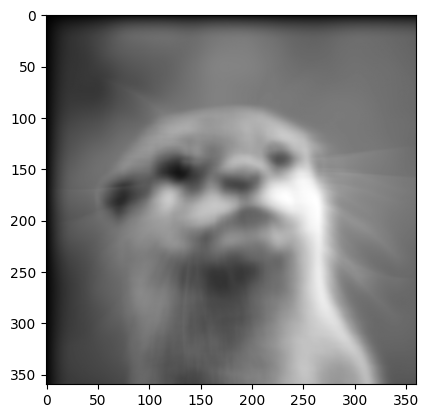

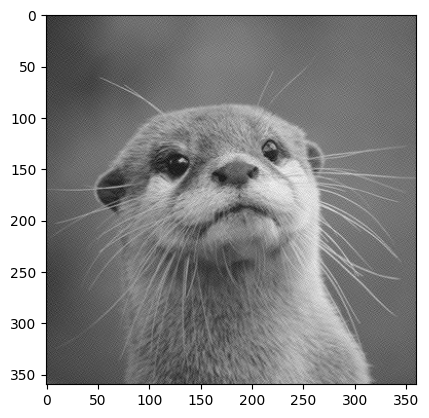

In [105]:
# blurred image from Problem 1
rng = np.random.default_rng(0)
# V and H are taken from Problem 1
otter_blurred = V @ otter @ H + 5 * rng.normal(size=(h, w))
plt.imshow(otter_blurred, cmap='gray')
plt.show()

# deblur the image
### Solution ###
H1=inverse(H)
V1=inverse(V)
otter= V1 @ otter_blurred @ H1
plt.imshow(otter, cmap='gray')
plt.show()
### Solution ###